In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [28]:
df = pd.read_csv("House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [30]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [31]:
df.shape

(2000, 10)

In [32]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [33]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [34]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


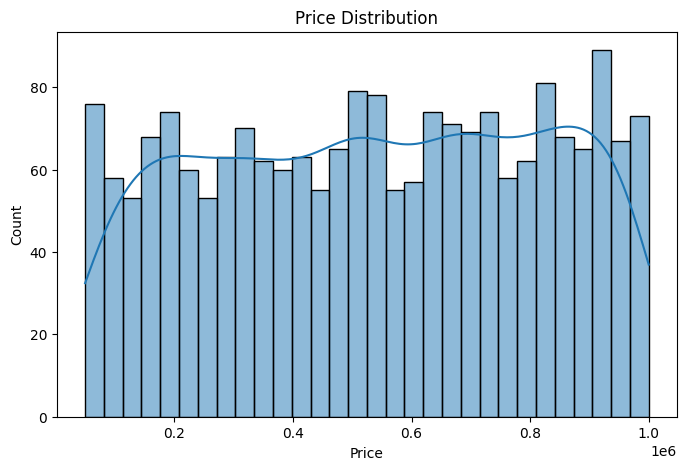

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

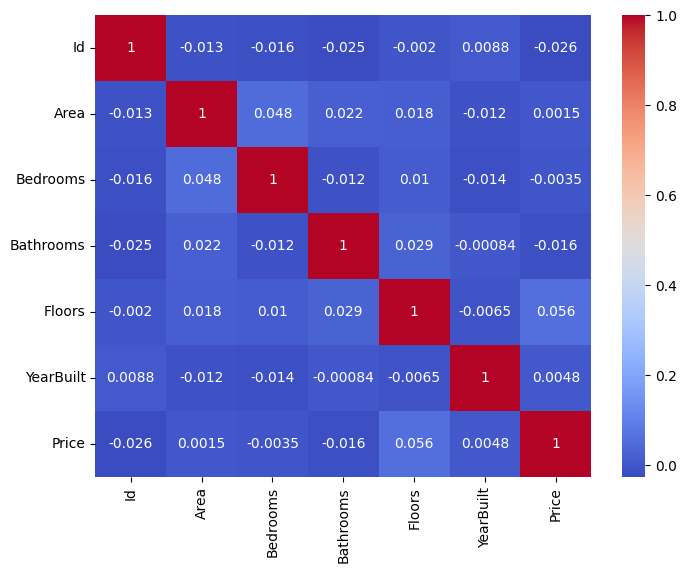

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.show()

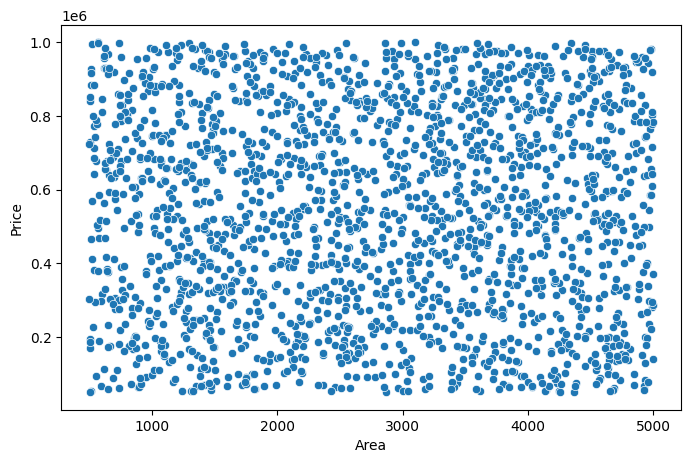

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Area",
    y="Price",
    data=df
)
plt.show()

In [38]:
le = LabelEncoder()
df["Location"] = le.fit_transform(df["Location"])
df["Condition"] = le.fit_transform(df["Condition"])
df["Garage"] = le.fit_transform(df["Garage"])

In [39]:
X = df.drop(["Id","Price"], axis=1)
y = df["Price"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
r2_lr = r2_score(y_test, lr_pred)
print("Linear Regression R2 Score =", r2_lr)

Linear Regression R2 Score = -0.011961539273188437


In [42]:
dt = DecisionTreeRegressor(
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
r2_dt = r2_score(y_test, dt_pred)
print("Decision Tree R2 Score =", r2_dt)

Decision Tree R2 Score = -1.1746784697777648


In [43]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
r2_rf = r2_score(y_test, rf_pred)
print("Random Forest R2 Score =", r2_rf)

Random Forest R2 Score = -0.10743569077376658


In [44]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score":[
        r2_lr,
        r2_dt,
        r2_rf
    ]
})
results

,Model,R2 Score
0,Linear Regression,-0.011962
1,Decision Tree,-1.174678
2,Random Forest,-0.107436


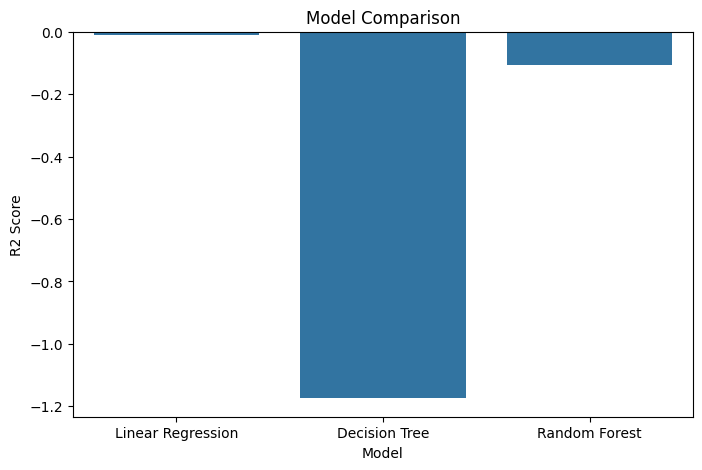

In [45]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Model",
    y="R2 Score",
    data=results
)
plt.title("Model Comparison")
plt.show()

In [46]:
print("MAE =",
      mean_absolute_error(y_test, rf_pred))
print("MSE =",
      mean_squared_error(y_test, rf_pred))
print("RMSE =",
      np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score =",
      r2_score(y_test, rf_pred))

MAE = 253932.662325
MSE = 86157199403.32457
RMSE = 293525.4663625025
R2 Score = -0.10743569077376658


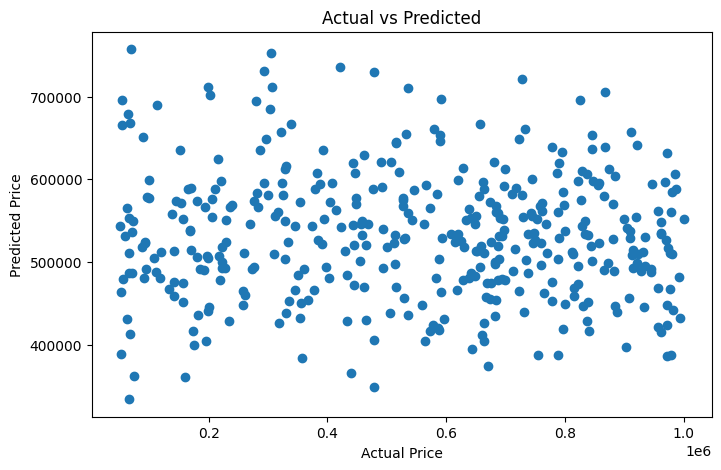

In [47]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [48]:
sample_house = X.iloc[[0]]
prediction = rf.predict(sample_house)
print("Predicted Price =", prediction[0])

Predicted Price = 290150.82
